In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
rng = None

#SIGMA_V, SIGMA_I, TAU_OU = 0.008, 0.02, 0.2
STEP_TIME = 0.001 # 10 ms
SIGMA_FREQ, TAU_OU = 0.1, 0.0001 # deviations + time-step 


# reset
def set_seed(seed):
    global rng, _state
    rng = np.random.default_rng(seed)
    _state = {'last_t': None, 'ou_vd': 0.0, 'ou_vq': 0.0, 'ou_id': 0.0, 'ou_iq': 0.0}

    print(f"rng set to: {seed}")

# Orenstein-Uhlenbeck Simulation 
def ou_step(x, dt, tau, sigma):
    decay = np.exp(-dt / tau)
    return x * decay + sigma * np.sqrt(1 - decay**2) * rng.standard_normal()


In [45]:
set_seed(42)
vals = pd.Series(0.5 * np.sin(3 * np.linspace(0, 2 * np.pi, 1000)) + 0.5)
vals_noisy = pd.Series()

for i in vals.index:
    vals_noisy[i] = vals[i] + ou_step(vals[i], 1, TAU_OU, SIGMA_FREQ)

rng set to: 42


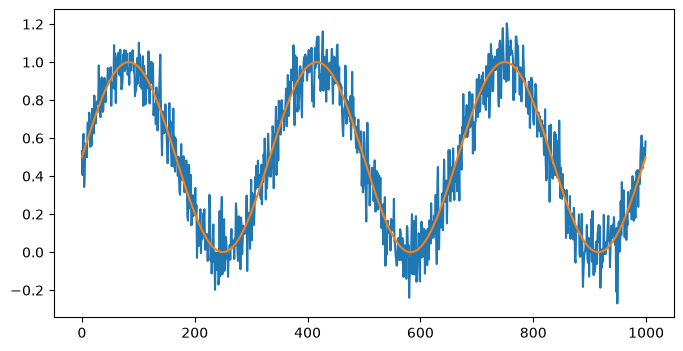

In [ ]:
fig,ax = plt.subplots(figsize=(8, 4))

ax.plot(vals_noisy.index, vals_noisy)
ax.plot(vals.index, vals)

#ax.set_ylim(0.9, 1.1)
#ax.set_xlim(5, 15)